In [ ]:
Venkatappareddy Manukonda

MSCS-634 Advanced Big Data and Data Mining

Data Visualization, Data Preprocessing, and Statistical Analysis Using Python

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('used_car_dataset.csv')

# Display first five rows
df.head()

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,Honda,City,2001,23,"98,000 km",Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000"
1,Toyota,Innova,2009,15,190000.0 km,Manual,second,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","₹ 3,75,000"
2,Volkswagen,VentoTest,2010,14,"77,246 km",Manual,first,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","₹ 1,84,999"
3,Maruti Suzuki,Swift,2017,7,"83,500 km",Manual,second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000"
4,Maruti Suzuki,Baleno,2019,5,"45,000 km",Automatic,first,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000"


In [4]:
df.columns.tolist()

['Brand',
 'model',
 'Year',
 'Age',
 'kmDriven',
 'Transmission',
 'Owner',
 'FuelType',
 'PostedDate',
 'AdditionInfo',
 'AskPrice']

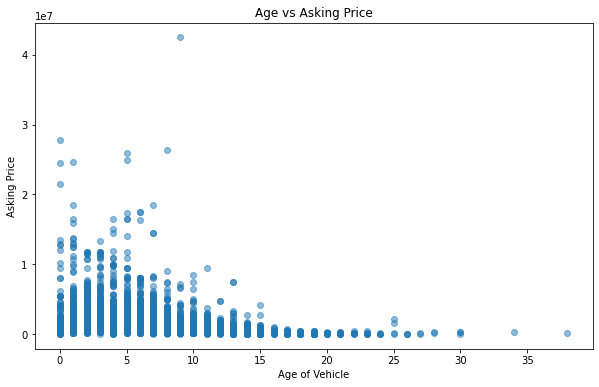

In [15]:
# Exploring whether vehicle age affects asking price
plt.figure(figsize=(10,6))

plt.scatter(df['Age'], df['AskPrice'], alpha=0.5)

plt.title('Age vs Asking Price')
plt.xlabel('Age of Vehicle')
plt.ylabel('Asking Price')

plt.show()

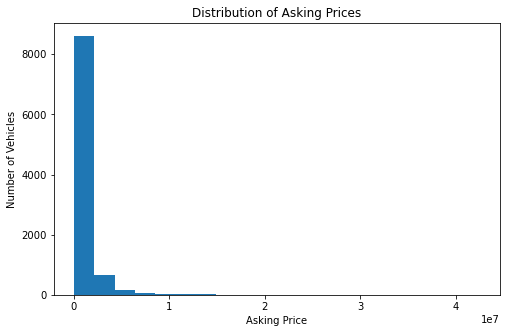

In [16]:
# Looking at how vehicle prices are distributed
plt.figure(figsize=(8,5))

plt.hist(df['AskPrice'], bins=20)

plt.title('Distribution of Asking Prices')
plt.xlabel('Asking Price')
plt.ylabel('Number of Vehicles')

plt.show()

In [17]:
# Checking for missing values
df.isnull().sum()

Brand            0
model            0
Year             0
Age              0
kmDriven        47
Transmission     0
Owner            0
FuelType         0
PostedDate       0
AdditionInfo     0
AskPrice         0
dtype: int64

In [21]:
# Removing commas and the 'km' text
df['kmDriven'] = df['kmDriven'].astype(str)

df['kmDriven'] = df['kmDriven'].str.replace(',', '', regex=False)
df['kmDriven'] = df['kmDriven'].str.replace(' km', '', regex=False)

# Convert to numeric
df['kmDriven'] = pd.to_numeric(df['kmDriven'], errors='coerce')

# Fill missing values with the average mileage
df['kmDriven'] = df['kmDriven'].fillna(df['kmDriven'].mean())

# Verify missing values are gone
df.isnull().sum()

Brand           0
model           0
Year            0
Age             0
kmDriven        0
Transmission    0
Owner           0
FuelType        0
PostedDate      0
AdditionInfo    0
AskPrice        0
dtype: int64

In [22]:
# Calculating the interquartile range for asking price

Q1 = df['AskPrice'].quantile(0.25)
Q3 = df['AskPrice'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 361000.0
Q3: 1125000.0
IQR: 764000.0
Lower Bound: -785000.0
Upper Bound: 2271000.0


In [23]:
# Finding vehicles with unusually high or low asking prices

outliers = df[(df['AskPrice'] < lower_bound) |
              (df['AskPrice'] > upper_bound)]

print("Number of Outliers:", len(outliers))

outliers.head()

Number of Outliers: 895


,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
7,BMW,5 Series,2019,5,25000.0,Automatic,second,Diesel,Nov-24,"BMW 5 Series 3.0 530D M Sport, 2019, Diesel",5950000
11,Kia,Carnival,2021,3,25000.0,Automatic,first,Diesel,Nov-24,"Kia Carnival Premium 8 STR, 2021, Diesel",2900000
14,Mercedes-Benz,GLE COUPE,2021,3,32000.0,Automatic,second,Petrol,Oct-24,Mercedes-Benz GLE COUPE 3.0 53 AMG 4MATIC Plus...,11800000
20,Ford,Endeavour,2019,5,77000.0,Automatic,second,Diesel,Nov-24,"Ford Endeavour 2.2 Titanium AT 4X2, 2019, Diesel",2399000
29,Toyota,2.8 Legender 4X2,2023,1,1996.0,Automatic,first,Diesel,Nov-24,"Toyota Fortuner Legender 4X4 AT 2.8, 2023, Diesel",4195000


In [24]:
# Removing outliers using the IQR boundaries

df_no_outliers = df[(df['AskPrice'] >= lower_bound) &
                    (df['AskPrice'] <= upper_bound)]

print("Original Shape:", df.shape)
print("New Shape:", df_no_outliers.shape)

Original Shape: (9582, 11)
New Shape: (8687, 11)


In [25]:
# Displaying dataset before reduction
df_no_outliers.head()

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,Honda,City,2001,23,98000.0,Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...",195000
1,Toyota,Innova,2009,15,190000.0,Manual,second,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...",375000
2,Volkswagen,VentoTest,2010,14,77246.0,Manual,first,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...",184999
3,Maruti Suzuki,Swift,2017,7,83500.0,Manual,second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,565000
4,Maruti Suzuki,Baleno,2019,5,45000.0,Automatic,first,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol",685000


In [26]:
# Removing columns that are not needed for analysis

df_reduced = df_no_outliers.drop(
    columns=['PostedDate', 'AdditionInfo']
)

df_reduced.head()

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,AskPrice
0,Honda,City,2001,23,98000.0,Manual,second,Petrol,195000
1,Toyota,Innova,2009,15,190000.0,Manual,second,Diesel,375000
2,Volkswagen,VentoTest,2010,14,77246.0,Manual,first,Diesel,184999
3,Maruti Suzuki,Swift,2017,7,83500.0,Manual,second,Diesel,565000
4,Maruti Suzuki,Baleno,2019,5,45000.0,Automatic,first,Petrol,685000


In [27]:
from sklearn.preprocessing import MinMaxScaler

# Scaling mileage and price values

scaler = MinMaxScaler()

df_reduced[['kmDriven', 'AskPrice']] = scaler.fit_transform(
    df_reduced[['kmDriven', 'AskPrice']]
)

df_reduced[['kmDriven', 'AskPrice']].head()

,kmDriven,AskPrice
0,0.100000,0.079787
1,0.193877,0.159574
2,0.078822,0.075354
3,0.085204,0.243794
4,0.045918,0.296986


In [28]:
# Creating price categories

df_reduced['PriceCategory'] = pd.cut(
    df_no_outliers['AskPrice'],
    bins=3,
    labels=['Economy', 'Standard', 'Premium']
)

df_reduced[['AskPrice', 'PriceCategory']].head()

,AskPrice,PriceCategory
0,0.079787,Economy
1,0.159574,Economy
2,0.075354,Economy
3,0.243794,Economy
4,0.296986,Economy


In [29]:
# General information about the dataset
df_reduced.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8687 entries, 0 to 9581
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Brand          8687 non-null   object  
 1   model          8687 non-null   object  
 2   Year           8687 non-null   int64   
 3   Age            8687 non-null   int64   
 4   kmDriven       8687 non-null   float64 
 5   Transmission   8687 non-null   object  
 6   Owner          8687 non-null   object  
 7   FuelType       8687 non-null   object  
 8   AskPrice       8687 non-null   float64 
 9   PriceCategory  8687 non-null   category
dtypes: category(1), float64(2), int64(2), object(5)
memory usage: 687.3+ KB


In [30]:
# Summary statistics
df_reduced.describe()

,Year,Age,kmDriven,AskPrice
count,8687.000000,8687.000000,8687.000000,8687.000000
mean,2016.073098,7.926902,0.074223,0.297678
std,4.091552,4.091552,0.057900,0.211908
min,1986.000000,0.000000,0.000000,0.000000
25%,2014.000000,5.000000,0.046939,0.146277
50%,2016.000000,8.000000,0.069388,0.237145
75%,2019.000000,10.000000,0.088775,0.390071
max,2024.000000,38.000000,1.000000,1.000000


In [31]:
# Central tendency measures for asking price

print("Minimum:", df_no_outliers['AskPrice'].min())
print("Maximum:", df_no_outliers['AskPrice'].max())
print("Mean:", df_no_outliers['AskPrice'].mean())
print("Median:", df_no_outliers['AskPrice'].median())
print("Mode:", df_no_outliers['AskPrice'].mode()[0])

Minimum: 15000
Maximum: 2271000
Mean: 686562.5289513066
Median: 550000.0
Mode: 450000


In [32]:
# Dispersion measures

price = df_no_outliers['AskPrice']

print("Range:", price.max() - price.min())
print("Q1:", price.quantile(0.25))
print("Q2 (Median):", price.quantile(0.50))
print("Q3:", price.quantile(0.75))
print("IQR:", price.quantile(0.75) - price.quantile(0.25))
print("Variance:", price.var())
print("Standard Deviation:", price.std())

Range: 2256000
Q1: 345000.0
Q2 (Median): 550000.0
Q3: 895000.0
IQR: 550000.0
Variance: 228546580046.53314
Standard Deviation: 478065.4558180638


In [33]:
# Selecting numerical columns

numeric_df = df_no_outliers.select_dtypes(include=['int64', 'float64'])

numeric_df.head()

,Year,Age,kmDriven,AskPrice
0,2001,23,98000.0,195000
1,2009,15,190000.0,375000
2,2010,14,77246.0,184999
3,2017,7,83500.0,565000
4,2019,5,45000.0,685000


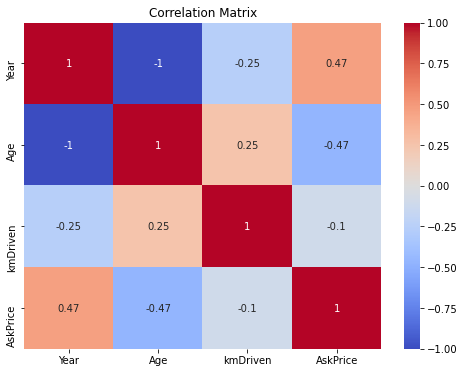

In [35]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()